In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/covid19-data-set/covid19 dataset/normal/Normal-859.png
/kaggle/input/covid19-data-set/covid19 dataset/normal/Normal-158.png
/kaggle/input/covid19-data-set/covid19 dataset/normal/Normal-10121.png
/kaggle/input/covid19-data-set/covid19 dataset/normal/Normal-1811.png
/kaggle/input/covid19-data-set/covid19 dataset/normal/Normal-97.png
/kaggle/input/covid19-data-set/covid19 dataset/normal/Normal-1088.png
/kaggle/input/covid19-data-set/covid19 dataset/normal/Normal-5663.png
/kaggle/input/covid19-data-set/covid19 dataset/normal/Normal-6328.png
/kaggle/input/covid19-data-set/covid19 dataset/normal/Normal-8410.png
/kaggle/input/covid19-data-set/covid19 dataset/normal/Normal-5641.png
/kaggle/input/covid19-data-set/covid19 dataset/normal/Normal-4852.png
/kaggle/input/covid19-data-set/covid19 dataset/normal/Normal-9518.png
/kaggle/input/covid19-data-set/covid19 dataset/normal/Normal-6443.png
/kaggle/input/covid19-data-set/covid19 dataset/normal/Normal-6391.png
/kaggle/input/covid19-d

In [1]:
# --- Imports ---
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report

# --- Constants ---
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32
EPOCHS = 10
BASE_DIR = "/kaggle/input/covid19-data-set/covid19 dataset"  

2025-06-12 08:39:08.642964: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749717549.114736      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749717549.241118      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# Define 70-30 split
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.3  # 🔹 This creates a 70-30 split
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.3)

# --- Data Generators ---
train_generator = train_datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',  # One-hot encoding
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',  # One-hot encoding
    subset='validation',
    shuffle=False
)

Found 9667 images belonging to 2 classes.
Found 4141 images belonging to 2 classes.


In [3]:
# --- Build the model with VGG16 ---
input_shape = (150, 150, 3)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
base_model.trainable = False  # Freeze pre-trained layers

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.1)(x)
outputs = Dense(2, activation='softmax')(x)  # 2 classes: COVID / non-COVID

model = Model(inputs=base_model.input, outputs=outputs)

I0000 00:00:1749717600.908148      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1749717600.908792      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 150, 150, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 150, 150, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 75, 75, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 75, 75, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 75, 75, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 37, 37, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 37, 37, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 37, 37, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 37, 37, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 18, 18, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 18, 18, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 18, 18, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 18, 18, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 9, 9, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 9, 9, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 9, 9, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 9, 9, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          65,6

 Total params: 14,780,610 (56.38 MB)

 Trainable params: 65,922 (257.51 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [5]:
# --- Compile the model ---
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])


In [8]:
# Add EarlyStopping callback
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [13]:
# Fit the model
import time
print(f"started to run")
start=time.time()
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop],  # Include callback here
    verbose=1
)
end=time.time()
print("finished running")
print(f"took {end-start} time to run")

started to run
Epoch 1/15
303/303 ━━━━━━━━━━━━━━━━━━━━ 114s 376ms/step - accuracy: 0.8701 - loss: 0.2991 - val_accuracy: 0.8942 - val_loss: 0.2667
Epoch 2/15
303/303 ━━━━━━━━━━━━━━━━━━━━ 114s 375ms/step - accuracy: 0.8765 - loss: 0.3025 - val_accuracy: 0.8993 - val_loss: 0.2675
Epoch 3/15
303/303 ━━━━━━━━━━━━━━━━━━━━ 117s 385ms/step - accuracy: 0.8769 - loss: 0.2962 - val_accuracy: 0.9017 - val_loss: 0.2613
Epoch 4/15
303/303 ━━━━━━━━━━━━━━━━━━━━ 110s 364ms/step - accuracy: 0.8841 - loss: 0.2884 - val_accuracy: 0.8988 - val_loss: 0.2601
Epoch 5/15
303/303 ━━━━━━━━━━━━━━━━━━━━ 108s 358ms/step - accuracy: 0.8851 - loss: 0.2844 - val_accuracy: 0.8935 - val_loss: 0.2686
Epoch 6/15
303/303 ━━━━━━━━━━━━━━━━━━━━ 110s 362ms/step - accuracy: 0.8811 - loss: 0.2877 - val_accuracy: 0.9053 - val_loss: 0.2495
Epoch 7/15
303/303 ━━━━━━━━━━━━━━━━━━━━ 111s 365ms/step - accuracy: 0.8819 - loss: 0.2809 - val_accuracy: 0.9073 - val_loss: 0.2464
Epoch 8/15
303/303 ━━━━━━━━━━━━━━━━━━━━ 112s 370ms/step - acc

In [14]:
# Training accuracy from last epoch
train_acc = history.history['accuracy'][-1]

# Validation (testing) accuracy from last epoch
val_acc = history.history['val_accuracy'][-1]

print(f"Training Accuracy: {train_acc * 100:.2f}%")
print(f"Validation Accuracy: {val_acc * 100:.2f}%")


Training Accuracy: 89.16%
Validation Accuracy: 90.90%


In [15]:
# Overall training accuracy
train_loss, train_acc = model.evaluate(train_generator)
print(f"Overall Training Accuracy: {train_acc * 100:.2f}%")

# Overall testing/validation accuracy
val_loss, val_acc = model.evaluate(val_generator)
print(f"Overall Validation Accuracy: {val_acc * 100:.2f}%")


303/303 ━━━━━━━━━━━━━━━━━━━━ 82s 269ms/step - accuracy: 0.8903 - loss: 0.2720
Overall Training Accuracy: 89.27%
130/130 ━━━━━━━━━━━━━━━━━━━━ 43s 334ms/step - accuracy: 0.8117 - loss: 0.4306
Overall Validation Accuracy: 90.05%


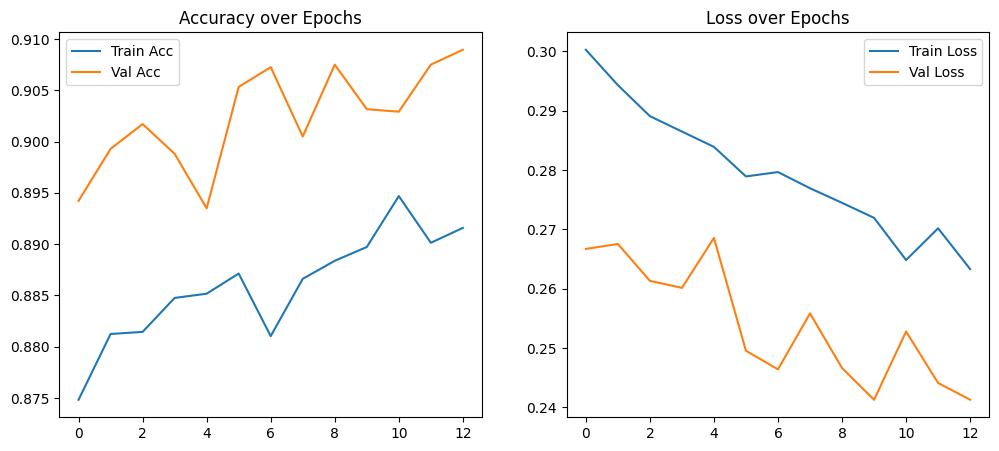

In [16]:
# --- Plot Accuracy and Loss ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()

130/130 ━━━━━━━━━━━━━━━━━━━━ 49s 372ms/step


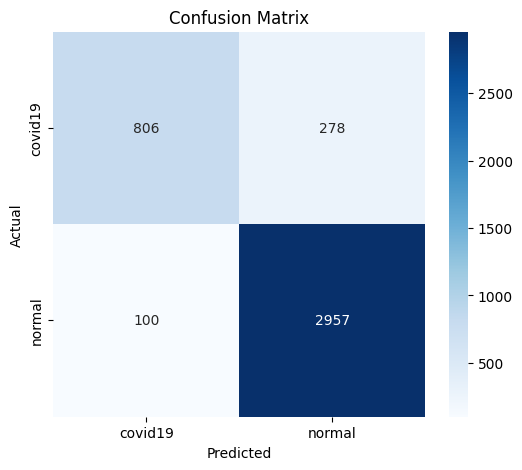

In [17]:

# --- Evaluate the model ---
val_preds = model.predict(val_generator)
y_pred = np.argmax(val_preds, axis=1)
y_true = val_generator.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=val_generator.class_indices, yticklabels=val_generator.class_indices)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [18]:
# Classification Report
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))

Classification Report:
               precision    recall  f1-score   support

     covid19       0.89      0.74      0.81      1084
      normal       0.91      0.97      0.94      3057

    accuracy                           0.91      4141
   macro avg       0.90      0.86      0.87      4141
weighted avg       0.91      0.91      0.91      4141



In [20]:
model.save("covid19vgg16_.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Prediction: No (Confidence: 99.84%)


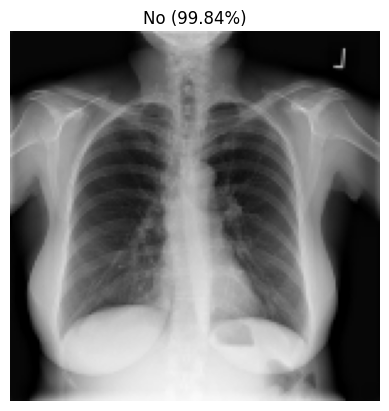

In [27]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load and preprocess image
img_path = "/kaggle/input/covid19-data-set/covid19 dataset/normal/Normal-10002.png"  
img = image.load_img(img_path, target_size=(150, 150))     
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Predict
prediction = model.predict(img_array)
confidence = float(prediction[0][0])
label = "Yes" if confidence >= 0.5 else "No"
confidence_percent = confidence*100 if label == "Yes" else (1 - confidence)*100

print(f"Prediction: {label} (Confidence: {confidence_percent:.2f}%)")

# Show image with label
plt.imshow(img)
plt.title(f"{label} ({confidence_percent:.2f}%)")
plt.axis('off')
plt.show()
